In [1]:
# Load libraries
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
#from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from datetime import datetime
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

In [2]:
# Define the ZIP file path and the Excel filename inside the ZIP
zip_path = "dataset/online_retail.zip"  
excel_filename = "Online Retail.xlsx"  

# Open the ZIP file and read the Excel file
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(excel_filename) as f:
        # Load the Excel file content 
        retail_df = pd.read_excel(f)

In [17]:
# Print the first few rows to check the data
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
print(retail_df.shape)

(541909, 8)


In [19]:
retail_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [20]:
# Check missing value
retail_df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [21]:
# convert date column to datetime objects
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Remove missing values and negative quantities
clean_data = retail_df.dropna(subset=['CustomerID'])
clean_data = clean_data[clean_data['Quantity'] > 0]

# Drop irrelevant column for the clustering
clean_data = clean_data.drop(columns=['Description', 'Country'])
print(clean_data.shape)

(397924, 6)


In [22]:
# RFM Analysis
snapshot_date = clean_data['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = clean_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',  # Frequency
    'UnitPrice': lambda x: (x * clean_data.loc[x.index, 'Quantity']).sum()  # Monetary Value
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [23]:
# Convert to DataFrame
rfm_df = rfm.reset_index()

print(rfm_df.shape)
print(rfm_df.head())

(4339, 4)
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2        182   4310.00
2     12348.0       75         31   1797.24
3     12349.0       19         73   1757.55
4     12350.0      310         17    334.40


In [24]:
# Merge on both df using inner join (common values)
merged_sales_df = pd.merge(clean_data, rfm_df, on='CustomerID', how='inner')
print(merged_sales_df.shape)

(397924, 9)


In [25]:
# Check missing value
merged_sales_df.isnull().sum().sort_values(ascending=False)

InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Recency        0
Frequency      0
Monetary       0
dtype: int64

In [26]:
print(merged_sales_df.shape)
print(merged_sales_df.columns)

(397924, 9)
Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Recency', 'Frequency', 'Monetary'],
      dtype='object')


In [27]:
# Load libraries
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

# Sample from the original full DataFrame
sampled_sales_df = merged_sales_df.sample(n=30000, random_state=42)

# Scale numeric features from the sample
scaler = StandardScaler()
sampled_scaled = scaler.fit_transform(sampled_sales_df[['Quantity', 'UnitPrice']])

In [28]:
# Compute Z-scores for the scaled data
z_scores = np.abs(zscore(sampled_scaled))

# Get rows with all Z-scores < 3
z_val = (z_scores < 3).all(axis=1)

# Filter both the scaled data and the original DataFrame
scaled_cleaned_df = sampled_scaled[z_val]
filtered_sales_df = sampled_sales_df[z_val].copy()

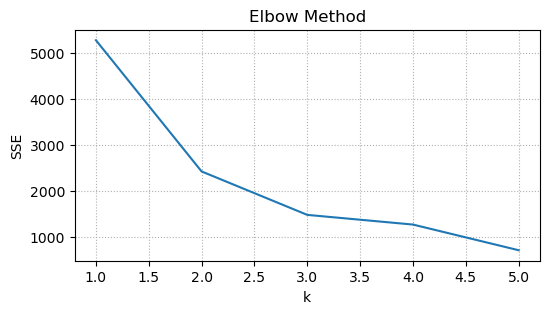

In [29]:
sse = {}
K = range(1,6)
for k in K:
    kmeans = KMeans(n_clusters=k).fit(scaled_cleaned_df)
    sse[k]= kmeans.inertia_
    
# Plot
plt.figure(figsize=(6, 3))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel('k')
plt.ylabel('SSE')
plt.grid(True, linestyle=':')
plt.title('Elbow Method')
plt.show()

In [30]:
print(scaled_cleaned_df.shape)       
print(scaled_cleaned_df)  

(29670, 2)
[[-0.30256726 -0.08259248]
 [ 0.14186046 -0.10480286]
 [-0.11956761 -0.06593469]
 ...
 [ 0.2987173   0.03401204]
 [-0.25028165  0.15616915]
 [-0.17185323  0.03401204]]


In [31]:
# Clustering Algorithms
# KMean clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_cleaned_df)

# Create GMM object
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(scaled_cleaned_df)

In [32]:
# for eps in [0.5, 1, 3, 5, 7, 9, 11, 13]:
#     print("\neps={}".format(eps))
#     for min_samples in [3, 2]:
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(scaled_cleaned_df)

#         n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#         n_noise = list(labels).count(-1)

#         print(f"min_samples={min_samples} - Clusters found: {n_clusters}")
#         print(f"min_samples={min_samples} - Noise points: {n_noise}")

In [19]:
# Check different values of eps and clusters
for eps in [0.5, 1, 3, 5, 7, 9, 11, 13]:
    print("\neps={}".format(eps))
    dbscan = DBSCAN(eps=eps, min_samples=3)
    dbscan_labels  = dbscan.fit_predict(scaled_cleaned_df)
    print("Clusters present: {}".format(np.unique(dbscan_labels )))
    print("Cluster sizes: {}".format(np.bincount(dbscan_labels  + 1)))


eps=0.5
Clusters present: [0 1]
Cluster sizes: [    0 29662     8]

eps=1
Clusters present: [0]
Cluster sizes: [    0 29670]

eps=3
Clusters present: [0]
Cluster sizes: [    0 29670]

eps=5
Clusters present: [0]
Cluster sizes: [    0 29670]

eps=7
Clusters present: [0]
Cluster sizes: [    0 29670]

eps=9
Clusters present: [0]
Cluster sizes: [    0 29670]

eps=11
Clusters present: [0]
Cluster sizes: [    0 29670]

eps=13
Clusters present: [0]
Cluster sizes: [    0 29670]


In [33]:
# Create DBSCAN object
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(scaled_cleaned_df)

In [34]:
from sklearn.cluster import AgglomerativeClustering

# Then do hierarchical clustering
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(scaled_cleaned_df)

In [35]:
# Add cluster labels to the dataframe
filtered_sales_df['KMeansCluster'] = cluster_labels
filtered_sales_df['AgglomerativeCluster'] = agglo_labels
filtered_sales_df['DBSCANCluster'] = dbscan_labels
filtered_sales_df['GMMCluster'] = gmm_labels

# Show the head of df
filtered_sales_df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Recency,Frequency,Monetary,KMeansCluster,AgglomerativeCluster,DBSCANCluster,GMMCluster
353660,577258,20727,1,2011-11-18 12:27:00,1.65,16764.0,4,706,2799.25,0,2,0,0
291366,571433,22733,18,2011-10-17 13:19:00,1.25,13015.0,53,176,3346.28,0,0,0,0
240576,566561,22367,8,2011-09-13 12:13:00,1.95,18145.0,13,221,2861.55,0,0,0,0
158978,556879,22622,1,2011-06-15 12:07:00,11.95,16461.0,178,33,151.42,2,2,0,2
225173,564742,23333,1,2011-08-28 15:01:00,1.25,17346.0,4,500,2676.56,0,2,0,2


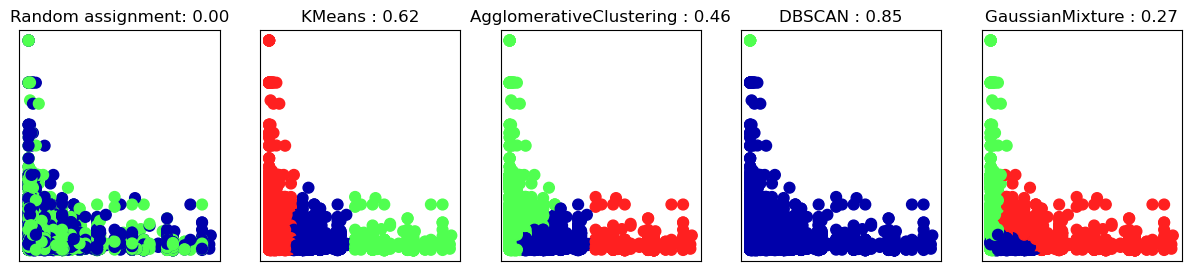

In [23]:
import mglearn

fig, axes = plt.subplots(1, 5, figsize=(15, 3),
                            subplot_kw={'xticks': (), 'yticks': ()})

# create a random cluster assignment for reference
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(scaled_cleaned_df))

# plot random assignment
axes[0].scatter(scaled_cleaned_df[:, 0], scaled_cleaned_df[:, 1], c=random_clusters,
    cmap=mglearn.cm3, s=60)
axes[0].set_title("Random assignment: {:.2f}".format(
    silhouette_score(scaled_cleaned_df, random_clusters)))

algorithms = [KMeans(n_clusters=3), AgglomerativeClustering(n_clusters=3),
                DBSCAN(), GaussianMixture(n_components=3)]
for ax, algorithm in zip(axes[1:], algorithms):
    clusters = algorithm.fit_predict(scaled_cleaned_df)
    
    # plot the cluster assignments and cluster centers
    ax.scatter(scaled_cleaned_df[:, 0], scaled_cleaned_df[:, 1], c=clusters, cmap=mglearn.cm3,
                s=60)
    ax.set_title("{} : {:.2f}".format(algorithm.__class__.__name__,
    silhouette_score(scaled_cleaned_df, clusters)))

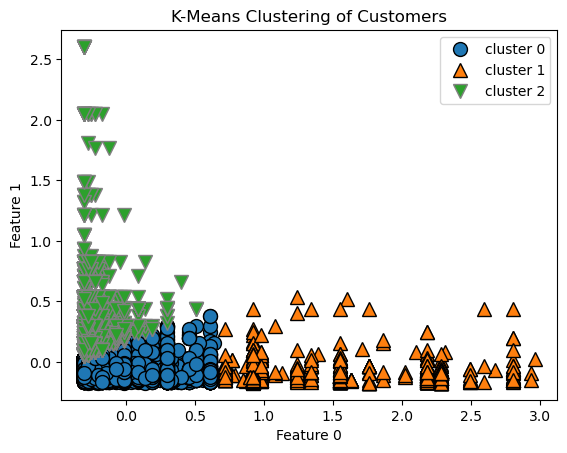

In [24]:
# Plt KMean clustering output
mglearn.discrete_scatter(scaled_cleaned_df[:, 0], scaled_cleaned_df[:, 1], cluster_labels)
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc='best')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title('K-Means Clustering of Customers')
plt.show()

In [25]:
filtered_sales_df.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Recency', 'Frequency', 'Monetary', 'KMeansCluster',
       'AgglomerativeCluster', 'DBSCANCluster', 'GMMCluster'],
      dtype='object')

In [36]:
# CLV Prediction

X_clv = filtered_sales_df[['Recency', 'Frequency', 'Monetary']]
y_clv = filtered_sales_df['Monetary'] 
rf_clv = RandomForestRegressor(random_state=42)
rf_clv.fit(X_clv, y_clv)
filtered_sales_df['Predicted_CLV'] = rf_clv.predict(X_clv)

# Churn Prediction
filtered_sales_df['Churn'] = (filtered_sales_df['Recency'] > filtered_sales_df['Recency'].median()).astype(int)
X_churn = filtered_sales_df[['Frequency', 'Monetary', 'Predicted_CLV']]
y_churn = filtered_sales_df['Churn']

In [37]:
# # Train model using logistic model
# logistic_regression = LogisticRegression(random_state=0)
# rf_churn = logistic_regression.fit(X_churn, y_churn)

# Train model using Random Forest model
# rf_churn = RandomForestClassifier(random_state=42)
# rf_churn.fit(X_churn, y_churn)
# rfm['Churn_Probability'] = rf_churn.predict_proba(X_churn)[:, 1]

# Train the EasyEnsembleClassifier
# rf_churn = EasyEnsembleClassifier(n_estimators=500, random_state=1) 
# rf_churn.fit(X_churn, y_churn)
# rfm['Churn_Probability'] = rf_churn.predict_proba(X_churn)[:, 1]

# Gradient Boosting model
churn_model = GradientBoostingClassifier(n_estimators=20,
                                        learning_rate=0.5,
                                        max_features=5,
                                        max_depth=3,
                                        random_state=0)
churn_model.fit(X_churn, y_churn)
filtered_sales_df['Churn_Probability'] = churn_model.predict_proba(X_churn)[:, 1]

In [38]:
# mean values of selected variables for each cluster
Kcluster_means = filtered_sales_df.groupby('KMeansCluster')[['Recency', 'Frequency', 'Monetary','Predicted_CLV', 'Churn_Probability']].mean()
Agglo_cluster_means = filtered_sales_df.groupby('AgglomerativeCluster')[['Recency', 'Frequency', 'Monetary','Predicted_CLV', 'Churn_Probability']].mean()
gmm_cluster_means = filtered_sales_df.groupby('GMMCluster')[['Recency', 'Frequency', 'Monetary','Predicted_CLV', 'Churn_Probability']].mean()
DB_cluster_means = filtered_sales_df.groupby('DBSCANCluster')[['Recency', 'Frequency', 'Monetary','Predicted_CLV', 'Churn_Probability']].mean()
print(Kcluster_means)
print(Agglo_cluster_means)
print(gmm_cluster_means)
print(DB_cluster_means)

                 Recency   Frequency      Monetary  Predicted_CLV  \
KMeansCluster                                                       
0              41.247661  640.660154   9066.883884    9066.869108   
1              29.824636  581.065013  44782.381754   44781.271657   
2              44.721248  708.772199  11142.196120   11142.196172   

               Churn_Probability  
KMeansCluster                     
0                       0.489896  
1                       0.387640  
2                       0.487246  
                        Recency   Frequency      Monetary  Predicted_CLV  \
AgglomerativeCluster                                                       
0                     40.907636  431.863200  11258.605796   11258.573136   
1                     25.443886  679.115578  63037.278744   63035.095672   
2                     42.228285  770.064851   8970.058771    8970.058846   

                      Churn_Probability  
AgglomerativeCluster                     
0             

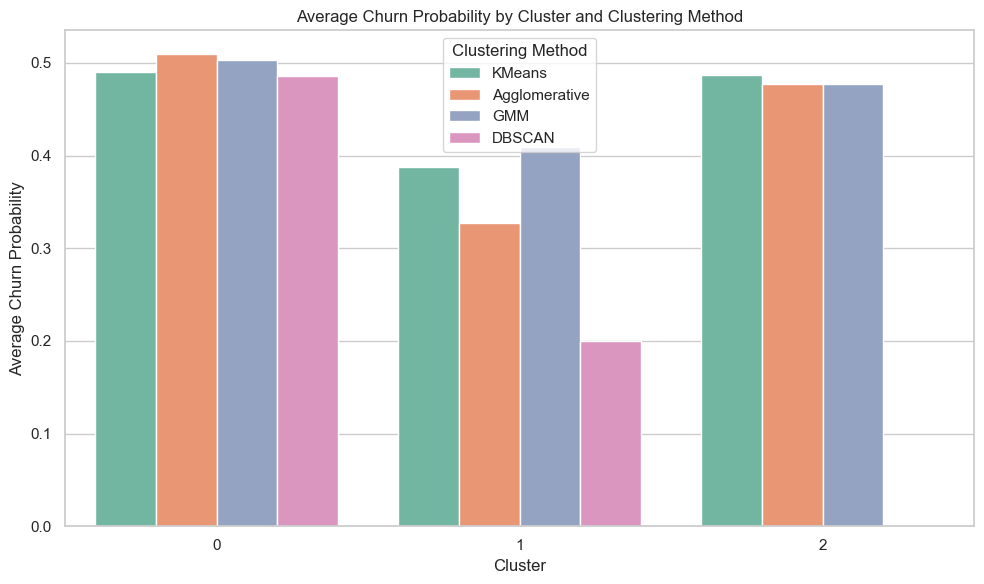

In [41]:
# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Prepare the data for plotting
cluster_churn_data = {
    'KMeans': filtered_sales_df.groupby('KMeansCluster')['Churn_Probability'].mean(),
    'Agglomerative': filtered_sales_df.groupby('AgglomerativeCluster')['Churn_Probability'].mean(),
    'GMM': filtered_sales_df.groupby('GMMCluster')['Churn_Probability'].mean(),
    'DBSCAN': filtered_sales_df.groupby('DBSCANCluster')['Churn_Probability'].mean()
}

# Convert to long format for seaborn
plot_df = []
for method, series in cluster_churn_data.items():
    for cluster, value in series.items():
        plot_df.append({
            'Clustering Method': method,
            'Cluster': cluster,
            'Average Churn Probability': value
        })

plot_df = pd.DataFrame(plot_df)

# Plot
sns.barplot(
    data=plot_df,
    x='Cluster',
    y='Average Churn Probability',
    hue='Clustering Method',
    palette='Set2'
)
plt.title('Average Churn Probability by Cluster and Clustering Method')
plt.tight_layout()
plt.show()

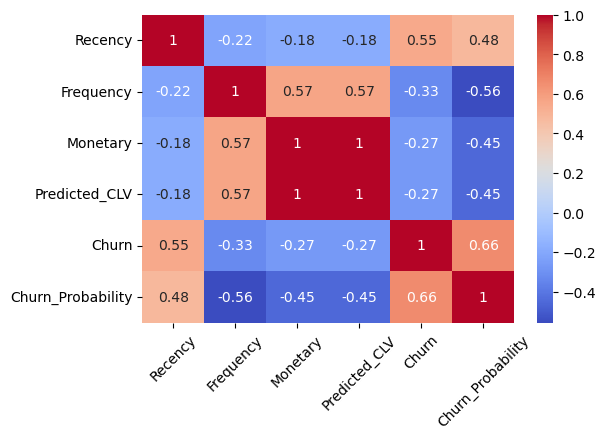

In [29]:
# Create a heatmap to show the correlation between features
corr = filtered_sales_df[['Recency', 'Frequency', 'Monetary','Predicted_CLV', 'Churn', 'Churn_Probability']]
correlation_matrix = corr.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.xticks(rotation=45)
plt.show()

In [30]:
# Predict CLV
y_pred_clv = rf_clv.predict(X_clv)

# Evaluate the model
mae_clv = mean_absolute_error(y_clv, y_pred_clv)
mse_clv = mean_squared_error(y_clv, y_pred_clv)
rmse_clv = np.sqrt(mse_clv)
r2_clv = r2_score(y_clv, y_pred_clv)

print("CLV Prediction Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_clv}")
print(f"Mean Squared Error (MSE): {mse_clv}")
print(f"Root Mean Squared Error (RMSE): {rmse_clv}")
print(f"R-squared (R²): {r2_clv}")

CLV Prediction Evaluation:
Mean Absolute Error (MAE): 0.06744448401221209
Mean Squared Error (MSE): 44.36036545810877
Root Mean Squared Error (RMSE): 6.660357757516391
R-squared (R²): 0.9999999487607738


In [31]:
# Predict Churn
y_pred_churn = churn_model.predict(X_churn)
y_prob_churn = churn_model.predict_proba(X_churn)[:, 1] 

# Evaluate the model
accuracy = accuracy_score(y_churn, y_pred_churn)
precision = precision_score(y_churn, y_pred_churn)
recall = recall_score(y_churn, y_pred_churn)
f1 = f1_score(y_churn, y_pred_churn)
conf_matrix = confusion_matrix(y_churn, y_pred_churn)
roc_auc = roc_auc_score(y_churn, y_prob_churn)

print("Churn Prediction Evaluation:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc}")

Churn Prediction Evaluation:
Accuracy: 0.8014492753623188
Precision: 0.760439695406534
Recall: 0.8615459542197176
F1-Score: 0.8078416022441857
Confusion Matrix:
[[11396  3901]
 [ 1990 12383]]
ROC-AUC: 0.8728043820005078


Clustering Performance:
                         KMeansCluster  AgglomerativeCluster    GMMCluster  \
Silhouette Score              0.423877              0.462506      0.274642   
Calinski-Harabasz Index   27988.338419          32508.448453  14778.889041   

                         DBSCANCluster  
Silhouette Score              0.853389  
Calinski-Harabasz Index     313.633945  

Sample RFM with Clusters:
       InvoiceNo StockCode  Quantity         InvoiceDate  UnitPrice  \
353660    577258     20727         1 2011-11-18 12:27:00       1.65   
291366    571433     22733        18 2011-10-17 13:19:00       1.25   
240576    566561     22367         8 2011-09-13 12:13:00       1.95   
158978    556879     22622         1 2011-06-15 12:07:00      11.95   
225173    564742     23333         1 2011-08-28 15:01:00       1.25   

        CustomerID  Recency  Frequency  Monetary  KMeansCluster  \
353660     16764.0        4        706   2799.25              0   
291366     13015.0       53   

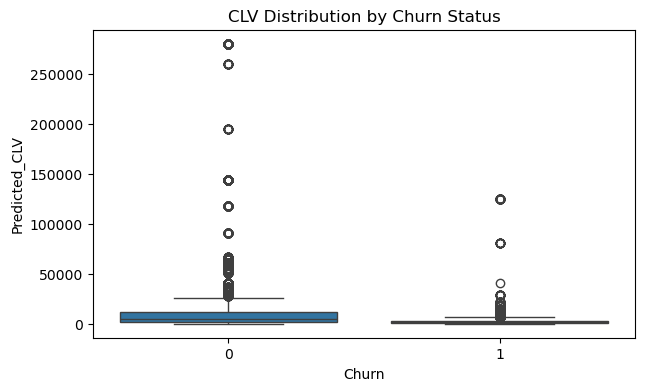

In [32]:
# Evaluate Clustering
metrics = {}
for method in ['KMeansCluster','AgglomerativeCluster', 'GMMCluster', 'DBSCANCluster']:
    metrics[method] = {
        'Silhouette Score': silhouette_score(scaled_cleaned_df, filtered_sales_df[method]),
        'Calinski-Harabasz Index': calinski_harabasz_score(scaled_cleaned_df, filtered_sales_df[method])
    }
print("Clustering Performance:")
print(pd.DataFrame(metrics))

print("\nSample RFM with Clusters:")
print(filtered_sales_df.head())

# Visualize Churn vs. CLV
plt.figure(figsize=(7, 4))
sns.boxplot(x=filtered_sales_df['Churn'], y=filtered_sales_df['Predicted_CLV'])
plt.title('CLV Distribution by Churn Status')
plt.show()


#### Clustering Performance Evaluation:

1. KMeansCluster:
   - Silhouette Score: 0.04239 – A relatively good score indicating that the points within the same cluster are close to each other, and the clusters are somewhat well separated.
   - Calinski-Harabasz Index: 27988.34 – A higher value indicates a better-defined clustering structure. This suggests that KMeans clustering is producing relatively distinct clusters in your dataset.

2. AgglomerativeCluster:
   - Silhouette Score: 0.4625 – Slightly lower than KMeans, indicating that while the clusters are reasonable, they are not as well-defined.
   - Calinski-Harabasz Index: 32508.45 – This value is smaller than KMeans, indicating that the clustering structure is not as clearly defined or separated as with KMeans.

3. DBSCANCluster:
   - Silhouette Score: 0.8534 – Very high, indicating that DBSCAN's clustering produces highly well-separated clusters. The high score suggests that DBSCAN is identifying distinct clusters.
   - Calinski-Harabasz Index: 313.63 – This value is very low, which is common with DBSCAN as it identifies noise points and may not have many clear cluster boundaries.
   - Noise Points: Based on the output, there are no noise points in DBSCAN, but the low Calinski-Harabasz score indicates that the defined clusters may not be as compact as the silhouette score suggests.

4. GMMCluster:
   - Silhouette Score: 0.2746 – Low score, indicating that the GMM clusters are not very well separated, and the clusters might overlap significantly.
   - Calinski-Harabasz Index: 14778.89 – A relatively low value, indicating that GMM's clustering structure isn't as well-defined as the other methods.

#### CLV and Churn Prediction Output Interpretation:

RFM Scores:  
   - Recency (R): Number of days since the last purchase.  
   - Frequency (F): Number of transactions made.  
   - Monetary (M): Total amount spent.

- Clusters: Each of the different clustering algorithms (KMeans, Agglomerative, DBSCAN, GMM) assigns cluster labels to customers. 
  - For example, Customer 353660 has a KMeansCluster label of `0`, while Customer 158985 has a KMeansCluster label of `2`. This shows that each customer is grouped differently by the algorithms.
  - Similarly, Predicted_CLV shows predicted customer lifetime value, and Churn shows whether a customer has churned (0 = no, 1 = yes).

- Churn Probability: 
  - Churn_Probability is high for some customers (like 0.922 for Customer 158978), meaning they have a high probability of churning. 
  - Others, like Customer 353660, have a low churn probability (0.075), indicating they are less likely to churn.

#### Key Insights:
1. Best Clustering Algorithm: DBSCAN has the highest silhouette score, meaning it provides the best clustering performance in terms of separating the data points. However, it has a low Calinski-Harabasz index, which may suggest the clusters might not be very compact, or there may be noise points.
2. KMeans: KMeans performed relatively well with a good silhouette score and a high Calinski-Harabasz index, making it a good choice for clearly separated clusters.
3. Agglomerative and GMM: Both have lower performance than DBSCAN and KMeans, with GMM showing the lowest silhouette score, indicating it might struggle with well-defined clusters.

#### Recommendations:
- DBSCAN seems to perform well in terms of separation (silhouette score), but further tuning of the `eps` parameter might help improve the clustering.
- KMeans might be a reliable choice if you're looking for clear, well-separated clusters, especially given the higher Calinski-Harabasz index.
- GMM should be used with caution as it has a low silhouette score and may not be suitable for your current dataset's structure. It might require further fine-tuning or a different initialization approach.

#### Summary of Cluster Characteristics:

**1. KMean:**
- `Cluster 0`: "Frequent, Moderate Spenders" or "Moderate Value, High Frequency". These are customers who buy often but spend moderately and have a moderate risk of churning.
- `Cluster 1`: "High Value, Infrequent Shoppers" or "Occasional High Spend Customers". These customers make fewer purchases but are highly valuable when they do buy. Their risk of churning is lower, likely because of their high monetary contribution.
- `Cluster 2`: "Frequent, Moderate Value Shoppers" or "Active, Medium Value Customers". These are customers who purchase frequently and have a higher predicted CLV than Cluster 0, but their spending is still not as high as the high-value customers in Cluster 1. 

**2. Agglomerative Clustering:**
- `Cluster 0`: "Occasional High Value Customers" or "Moderate Frequency, Moderate Value". These customers make infrequent purchases but tend to spend a reasonable amount each time. There is a moderate risk of churn.
- `Cluster 1`: "Frequent, High Value Customers" or "High Engagement, High Spend". These customers purchase frequently and spend significantly, with a low churn probability, indicating strong loyalty.
- `Cluster 2`: "Highly Active, Moderate Spend" or "Frequent Low-Value Shoppers". These customers are frequent shoppers but don't spend as much per transaction as Cluster 1. They have a moderate churn risk.

**3. GMM Clustering:**
- `Cluster 0`: Moderate-frequency, moderate-value customers with moderate churn risk.
- `Cluster 1`: Moderate-frequency, high-value customers with low churn risk.
- `Cluster 2`: Highly frequent, moderate-to-high-value customers with moderate churn risk.

**4. DBSCAN Clustering:**
- `Cluster 0`: Moderate-frequency, moderate-value customers with moderate churn risk.
- `Cluster 1`: Extremely high-value, highly frequent customers with very low churn risk.

#### Recommendations for Targeting:

- `KMean Cluster 0`: These customers might benefit from loyalty programs or incentives that encourage more purchases to increase their CLV.
- `KMean Cluster 1`: Since they are high-value but infrequent, you may want to focus on retention efforts for these customers, ensuring they don’t churn and continue making high-value purchases.
- `KMeanCluster 2`: Offering promotions or discounts could encourage them to spend more, as they already have high purchase frequency. You can also explore cross-selling or upselling strategies for these customers.
  
- `Agglomerative Cluster 1` and `GMM Cluster 1`: Target for loyalty programs and premium offers due to their high spend and low churn.
- `Agglomerative Cluster 0` and `GMM Cluster 0`: These customers might benefit from retargeting or re-engagement campaigns to increase purchase frequency and reduce churn.
- `DBSCAN Cluster 1`: Focus on retaining these ultra-high-value customers with personalized services to keep churn at bay.



In [33]:
print(filtered_sales_df.columns)

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Recency', 'Frequency', 'Monetary', 'KMeansCluster',
       'AgglomerativeCluster', 'DBSCANCluster', 'GMMCluster', 'Predicted_CLV',
       'Churn', 'Churn_Probability'],
      dtype='object')


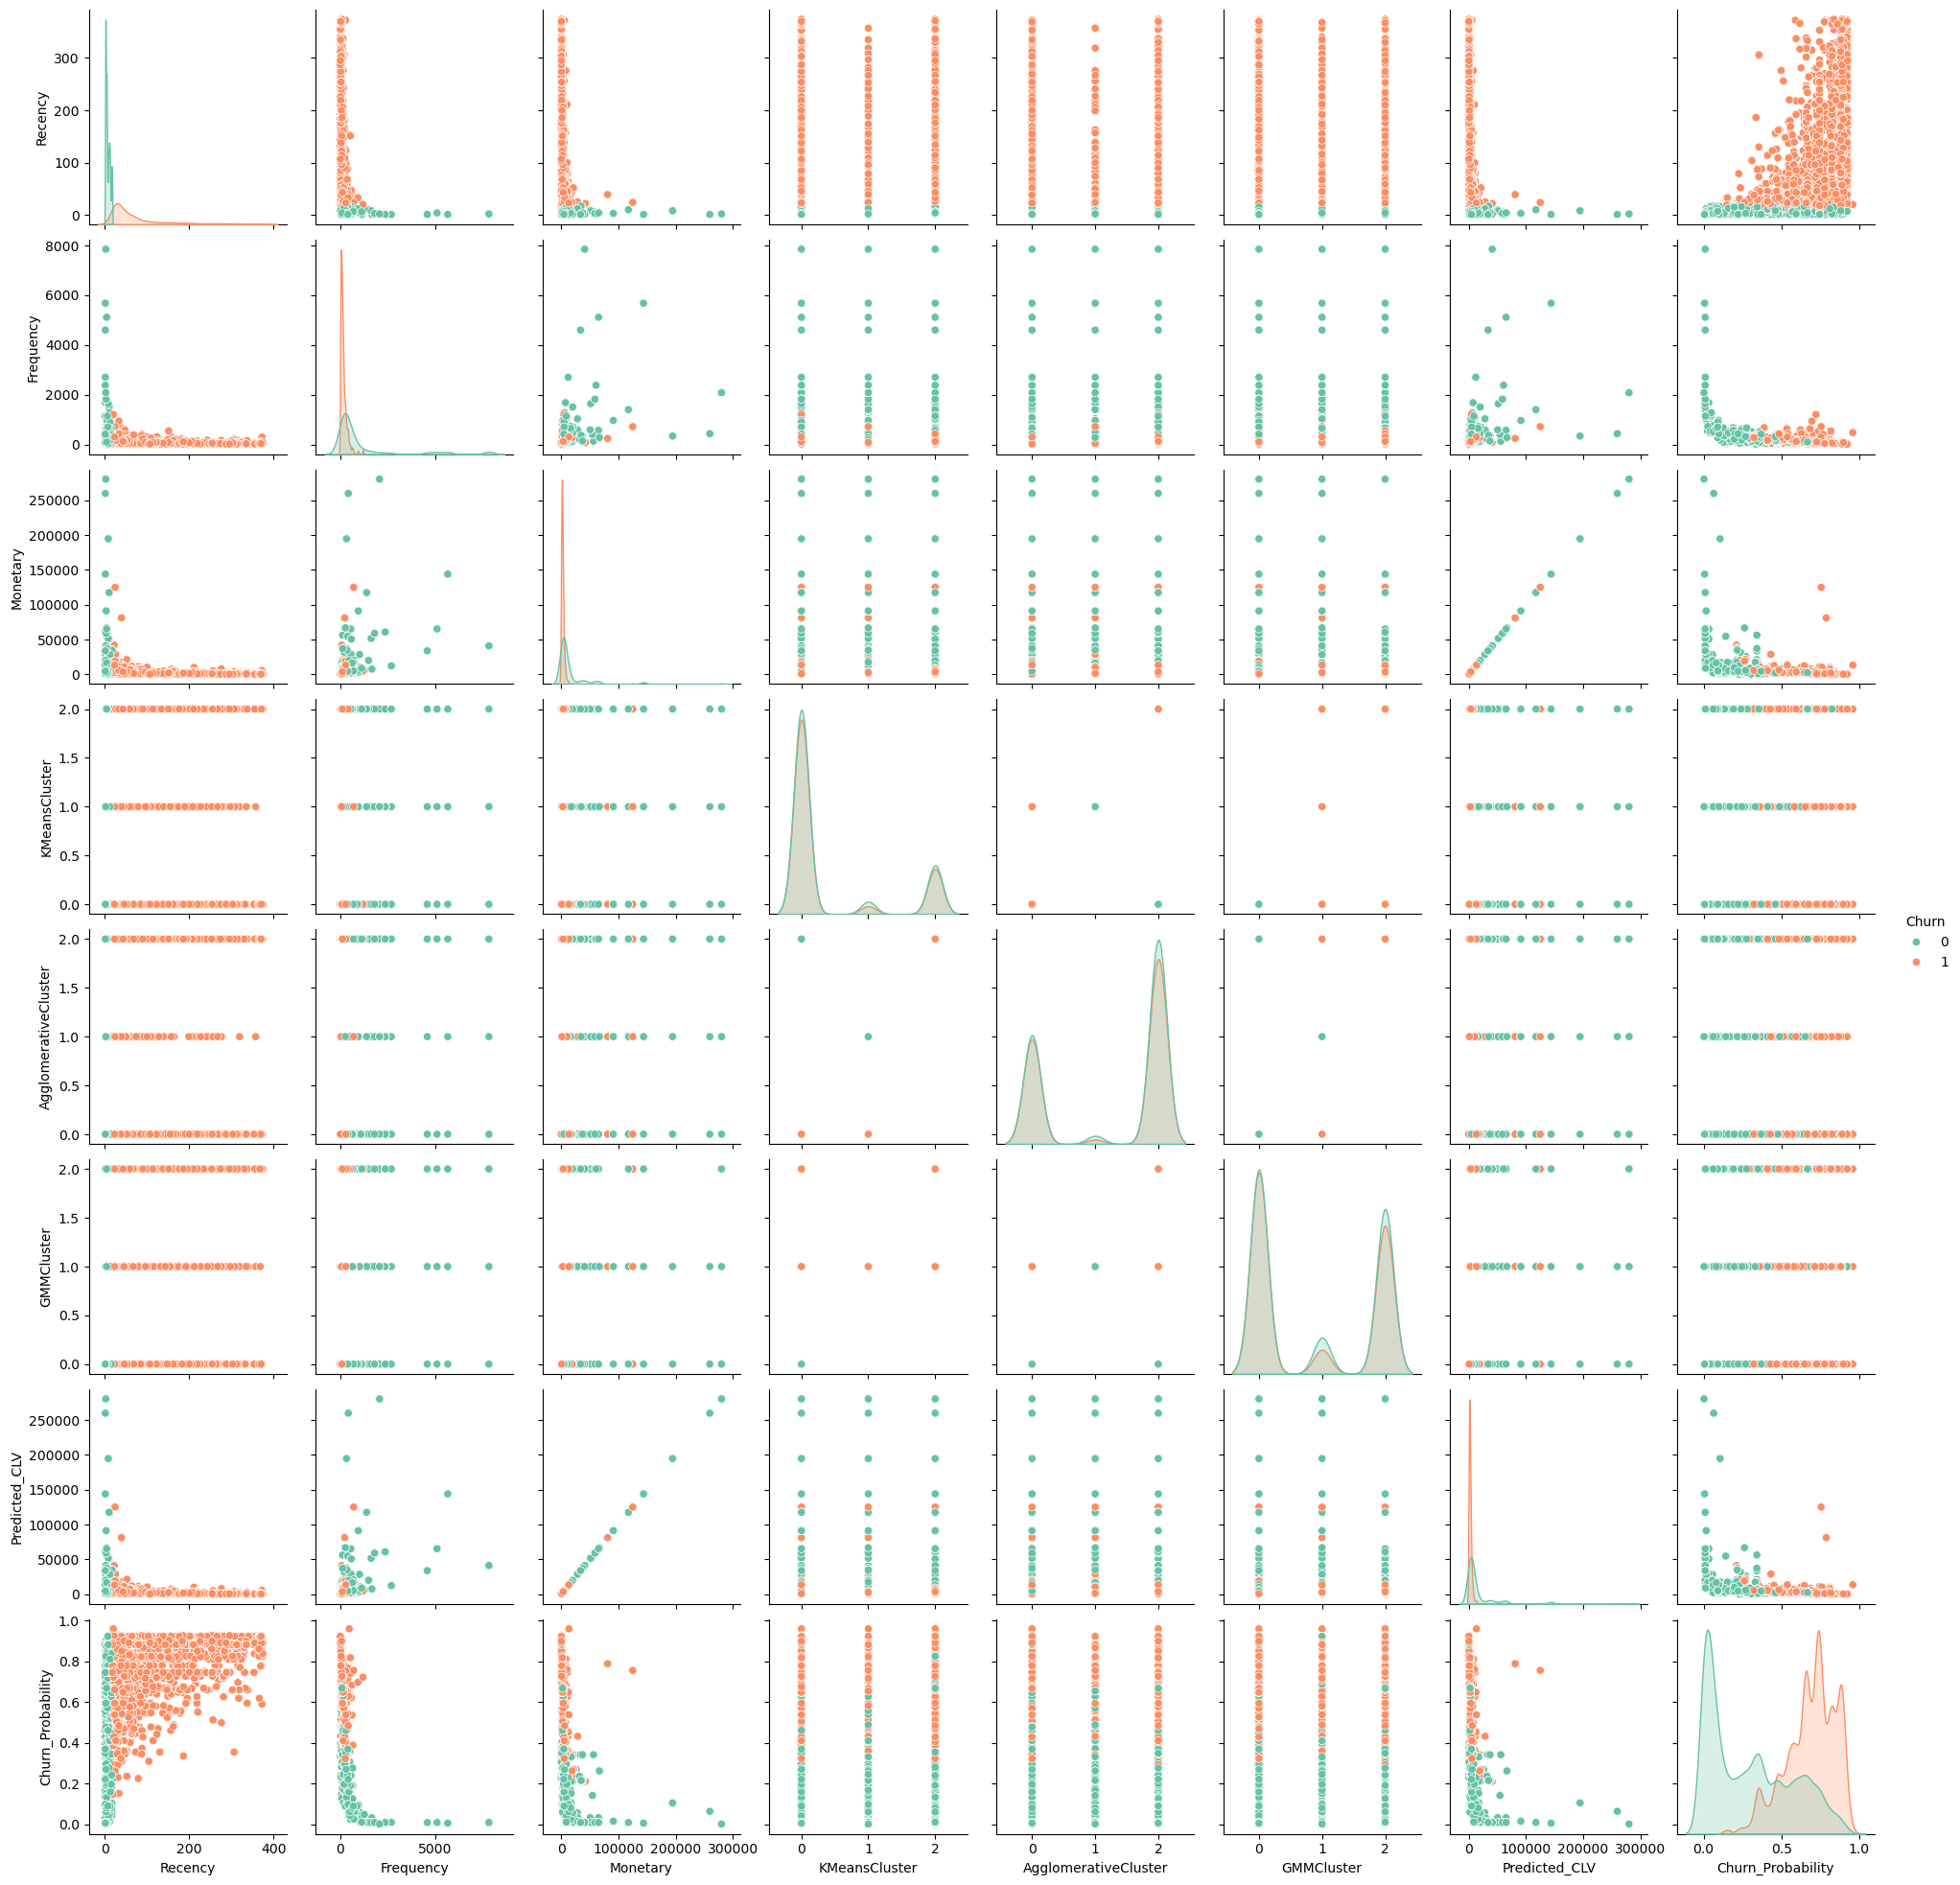

In [34]:
# Select variables for sns plot
selected_var = filtered_sales_df[['Recency', 'Frequency', 'Monetary','KMeansCluster',
       'AgglomerativeCluster', 'GMMCluster','Predicted_CLV', 'Churn', 'Churn_Probability']]

# Visualizing using Scatter Plots
sns.pairplot(selected_var, diag_kind='kde', hue='Churn', palette='Set2')
plt.show()

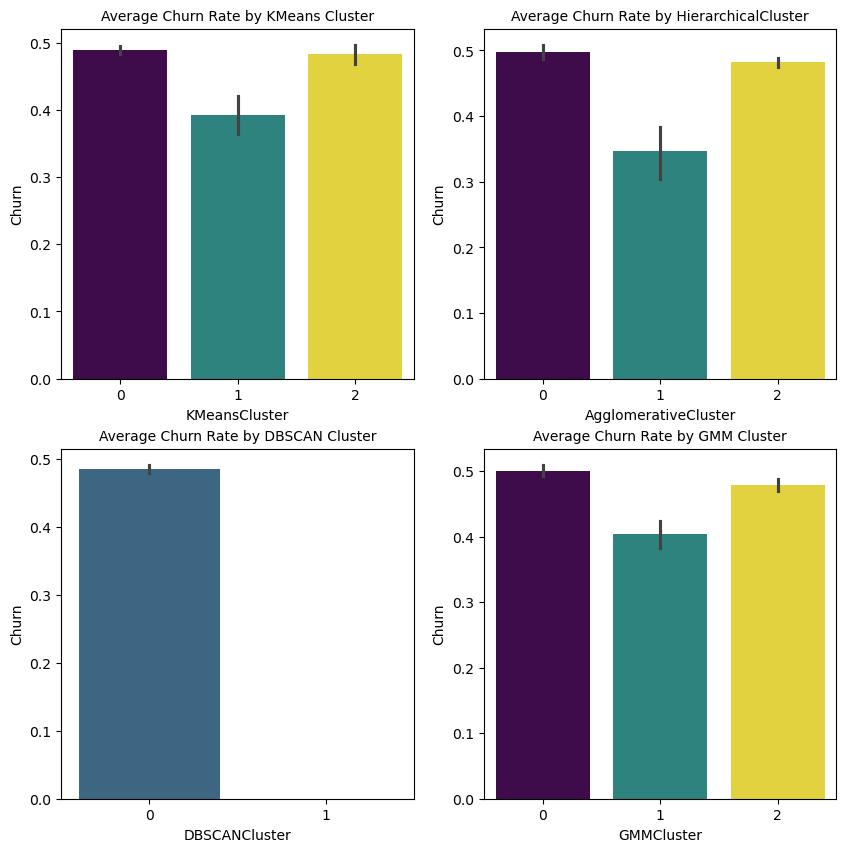

<Figure size 500x300 with 0 Axes>

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plt.figure(figsize=(5, 3))


# Plotting KMeans cluster analysis 
sns.barplot(x='KMeansCluster', y='Churn',
                hue='KMeansCluster', estimator=np.mean, palette='viridis', data=filtered_sales_df, ax=axes[0, 0])
axes[0, 0].set_title('Average Churn Rate by KMeans Cluster', fontsize=10)
axes[0, 0].legend_.remove() 
# # Plotting Hierarchical cluster analysis 
sns.barplot(x='AgglomerativeCluster', y='Churn',
                hue='AgglomerativeCluster', estimator=np.mean, palette='viridis', data=filtered_sales_df, ax=axes[0, 1])
axes[0, 1].set_title('Average Churn Rate by HierarchicalCluster', fontsize=10)
axes[0, 1].legend_.remove() 

# # Plotting DBSCAN cluster analysis 
sns.barplot(x='DBSCANCluster', y='Churn',
                hue='DBSCANCluster', estimator=np.mean, palette='viridis', data=filtered_sales_df, ax=axes[1, 0])
axes[1, 0].set_title('Average Churn Rate by DBSCAN Cluster', fontsize=10)
axes[1, 0].legend_.remove() 

# # Plotting GMM cluster analysis  
sns.barplot(x='GMMCluster', y='Churn',
                hue='GMMCluster', estimator=np.mean, palette='viridis', data=filtered_sales_df, ax=axes[1, 1])
axes[1, 1].set_title('Average Churn Rate by GMM Cluster', fontsize=10)
axes[1, 1].legend_.remove() 

# Adjust layout for better spacing
plt.tight_layout()
plt.suptitle("Cluster Analysis: Churn vs CLV", y=1.02, fontsize=16)
plt.show()

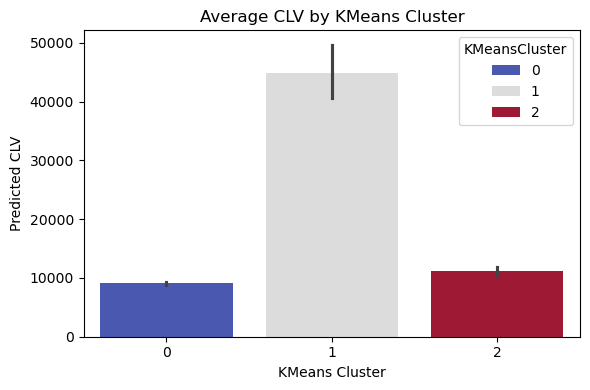

In [36]:
# Average CLV by Cluster (KMeans)
plt.figure(figsize=(6, 4))
sns.barplot(
    data=filtered_sales_df, 
    x='KMeansCluster', 
    y='Predicted_CLV', 
    hue='KMeansCluster', 
    estimator=np.mean, 
palette='coolwarm')
plt.title('Average CLV by KMeans Cluster')
plt.ylabel('Predicted CLV')
plt.xlabel('KMeans Cluster')
plt.tight_layout()
plt.show()

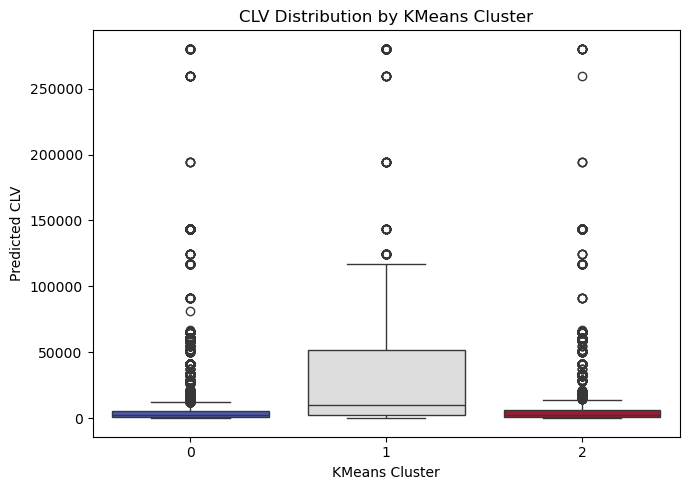

In [37]:
# CLV Distribution per Cluster 
plt.figure(figsize=(7, 5))
sns.boxplot(data=filtered_sales_df, 
            x='KMeansCluster', 
            y='Predicted_CLV', 
            hue='KMeansCluster',
            palette='coolwarm')
plt.title('CLV Distribution by KMeans Cluster')
plt.xlabel('KMeans Cluster')
plt.ylabel('Predicted CLV')
plt.tight_layout()
# Remove the legend
plt.legend([], [], frameon=False)
plt.show()

Intepretation:

* `Cluster 0`: This cluster exhibits a very low median CLV, close to zero. The majority of customers in this cluster have a predicted CLV that falls within a very narrow range near the bottom of the scale. However, there are several high outliers, indicating a small number of customers in this cluster with significantly higher predicted lifetime values.

* `Cluster 1`: This cluster shows a significantly higher median CLV compared to Cluster 0. The box itself is much taller, indicating a wider spread in the predicted CLV for customers in this group. While there are still outliers on the higher end, the central tendency and the interquartile range suggest that customers in Cluster 1 are generally expected to have a higher lifetime value than those in Cluster 0.

* `Cluster 2`: Similar to Cluster 0, this cluster displays a very low median CLV, again close to zero. The distribution is also concentrated at the lower end of the CLV scale. Like Cluster 0, there are also several high outliers, suggesting a few customers with much higher predicted lifetime values within this cluster.



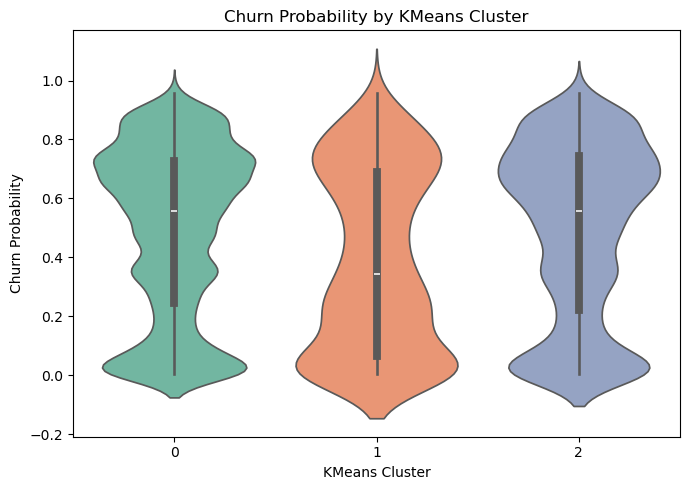

In [38]:
# Churn Probability Distribution by Cluster
plt.figure(figsize=(7, 5))
sns.violinplot(
    data=filtered_sales_df, 
    x='KMeansCluster', 
    y='Churn_Probability', 
    hue='KMeansCluster',
    palette='Set2')
plt.title('Churn Probability by KMeans Cluster')
plt.xlabel('KMeans Cluster')
plt.ylabel('Churn Probability')
plt.tight_layout()
# Remove the legend
plt.legend([], [], frameon=False)
plt.show()

Intepretations:

* `Cluster 0`: This cluster has a relatively wide distribution of churn probabilities, suggesting a diverse group of customers in terms of their likelihood to churn. The median churn probability appears to be around 0.5, but there's a significant spread, with some customers having very low probabilities and others having quite high probabilities.

* `Cluster 1`: Unexpectedly this cluster appears to have the highest overall churn probability compared to the other two. The bulk of the distribution is shifted towards higher churn probabilities, and the median seems to be above 0.6. This suggests that customers in this cluster are generally more likely to churn. This cluster is a cluster with high CLV value, this group should be the primary focus of churn prevention efforts.

* `Cluster 2`: This cluster shows a distribution of churn probabilities that is somewhat similar to Cluster 0, but with a tendency towards slightly lower churn probabilities. The median appears to be around 0.4 to 0.5. While there's still a spread, the upper tail of the distribution (very high churn probabilities) seems less pronounced than in Cluster 0 and significantly less than in Cluster 1.